In [ ]:
"This notebook is for calculating single cell RNA velocity with Dynamo."

In [2]:
import dynamo as dyn
import numpy as np
from scipy import stats,signal
from matplotlib import pyplot as plt
from scipy import sparse
from sklearn.neighbors import KernelDensity
import networkx as nx
import os
from numpy.random import randint

In [3]:
result_path='result/'
gene_arr=np.load(result_path+'EG_bin_genes.npy',allow_pickle=True)
dim_n=10
adata=dyn.read(result_path+'EG_ori_bin.h5ad')

/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


|-----? dynamo.preprocessing.deprecated is deprecated.
|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True
|-----> apply Monocole recipe to adata...
|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----> filtering cells...
|-----> 3467 cells passed basic filters.
|-----> filtering gene...
|-----> 27 genes passed basic filters.
|-----> calculating size factor...
|-----? only 27 genes passed basic filtering, but you requested 2000 genes for feature selection. Try lowering the gene selection stringency: {'min_expr_cells': 0, 'min_expr_avg': 0, 'max_expr_avg': inf, 'svr_gamma': None, 'winsorize': False, 'winsor_perc': (1, 99.5), 'sort_inverse': False}
|-----> selecting genes in layer: X, sort method: SVR...
|-----> Discarding genes that failed the filtering...
|-----> size factor

estimating gamma: 100%|██████████| 41/41 [00:00<00:00, 438.80it/s]


╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 5.3895s                                                 │
│  Shape:    3,567 x 41 (Unchanged)                                  │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ vel_params_names                                     │
│                                                                    │
│  ● OBSP   │ ✚ moments_con (sparse matrix, 3567x3567)               │
│                                                                    │
│  ● LAYERS │ ✚ M_s (sparse matrix, 3567x41)                         │
│    

|-----> <insert> X_umap to obsm in AnnData Object.
|-----> [UMAP] completed [6.8120s]

╭─ SUMMARY: reduceDimension ─────────────────────────────────────────╮
│  Duration: 6.8128s                                                 │
│  Shape:    3,567 x 41 (Unchanged)                                  │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 30, 'method': 'umap'}       │
│           │ ✚ umap_fit                                             │
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 3567x2)                               │
│                                                                    │
╰────────────────────────────────────────────────────────────

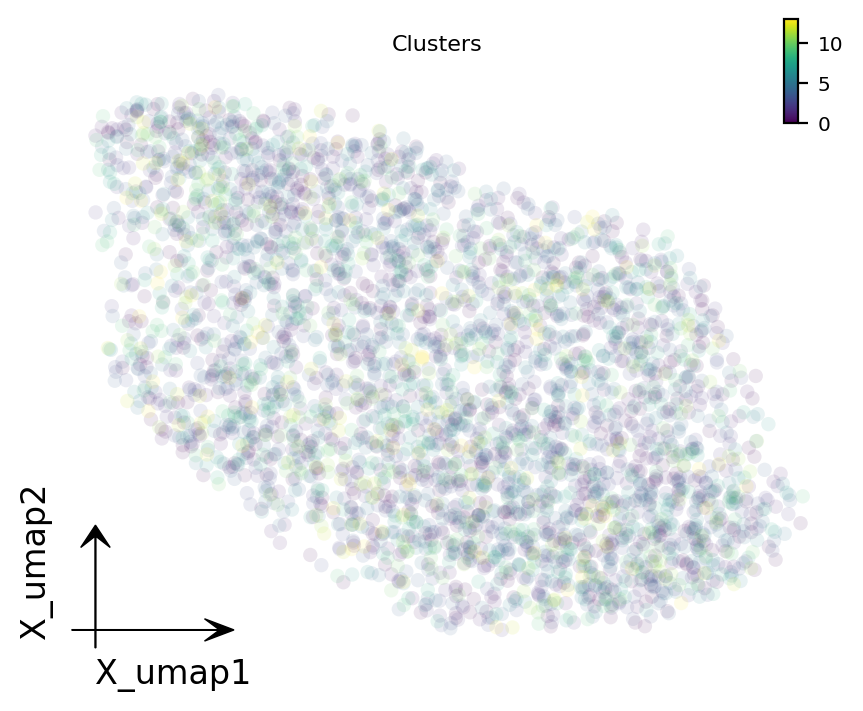

In [4]:
dyn.pp.recipe_monocle(adata,keep_filtered_genes=False,keep_filtered_cells=True)

dyn.tl.dynamics(adata,assumption_mRNA='auto')

dyn.tl.reduceDimension(
    adata,
    n_pca_components=5
)

# dyn.tl.reduceDimension(adata)
dyn.pl.umap(adata, color='Clusters',pointsize=0.1)

In [10]:
dyn.tl.cell_velocities(
    adata,
    method='fp',
    basis='pca',
    correct_density=False
)

|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.2237s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected

╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮
│  Duration: 2.9377s                                                 │
│  Shape:    3,567 x 41 (Unchanged)                                  │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ grid_velocity_pca                                    │
│                                                                    │
│  ● OBSP   │ ✚ discrete_vector_field (array, 3567x3567)             │
│           │ ✚ fp_transition_matrix (sparse matrix, 3567x3567)      │
│           │ ✚

AnnData object with n_obs × n_vars = 3567 × 41
    obs: 'Clusters', '_X', '_Y', 'batch', 'obs_names', 'treatment', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'var_names', 'nCells', 'nCounts', 'pass_basic_filter', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'pp', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'pca_fit', 'feature_selection', 'history_log', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_pca'
    obsm: 'X_pca', 'X', 'X_umap', 'velocity_pca'
    varm: 'vel_params'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'X_unspliced', 'X_spliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss', 'velocity_S'
    obsp: 'moments_con', 'distances', 'connectivities', 'fp_transition_rate', 'discrete_vector_fiel

|-----------> plotting with basis key=X_pca


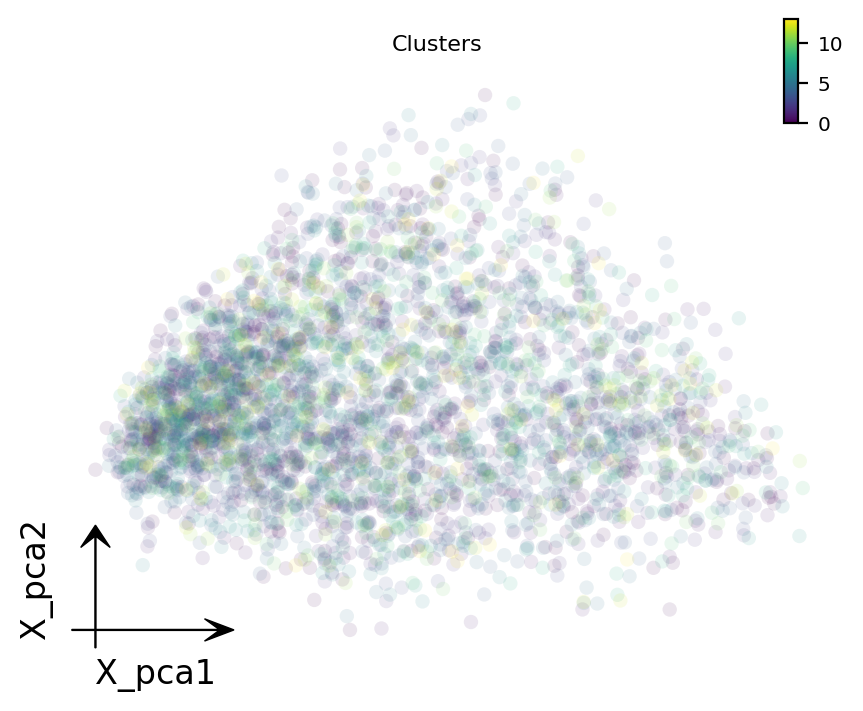

In [14]:
dyn.pl.pca(adata, color='Clusters',pointsize=0.1)

In [ ]:
adata.write(result_path+'EG_dyn.h5ad')